In [1]:
# Standard library
import json
import os
import re
import sys
from pathlib import Path

# Third-party
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy import stats
from scipy.interpolate import interp1d

# Root dir
ROOT = Path(os.getcwd()).resolve()
sys.path.append(str(ROOT/'src'))

# Local
from utils import gaussian_smoothing, moving_average

## Training Loss vs Compute

### Training data

In [3]:
# results directory
lr = '0.0000016'
dir_path = ROOT/f'results/slim_pajama/lr_{lr}/'
    
# smoothing parameters
sigma = 70
window_size = 3 * sigma

# data dict
flops_and_losses = {}

for file_path in dir_path.iterdir():
    if file_path.is_file():
        with open(file_path, 'r') as file:
            # load results dict
            results = json.load(file)

            # params
            n_params = results['n_params']

            # flops
            total_batches = results['total_batches']
            total_flops = results['n_flops']
            flops = np.linspace(0, total_flops, total_batches)
            flops = flops[window_size:-window_size + 1]

            # smoothed losses
            losses = results['losses']
            # smooth_losses = moving_average(losses, window_size)
            smooth_losses = gaussian_smoothing(losses, sigma, window_size)

            # create dict entry if it doesn't exist
            if n_params not in flops_and_losses:
                flops_and_losses[n_params] = []
                
            # add to dict
            flops_and_losses[n_params].append((flops, smooth_losses))

### Pareto frontier

In [60]:
# interpolation functions
min_flops = 1e15
max_flops = float('-inf')
interp_fcns = []
for f_l_lists in flops_and_losses.values():
    for f_list, l_list in f_l_lists:
        max_flops = max(max_flops, f_list[-1])
        interp_fcns.append(interp1d(f_list, l_list, bounds_error=False, 
                                    fill_value=float('inf')))
print(f'Min flops = {min_flops:.2e}')
print(f'Max flops = {max_flops:.2e}')

# pareto frontier
all_flops = np.logspace(np.log10(min_flops), np.log10(max_flops), 100)[1:-1]
pareto = {f: min(fcn(f) for fcn in interp_fcns) for f in all_flops}

# line of best fit
regress = stats.linregress(np.log2(all_flops), np.log2(list(pareto.values())))
pareto_lobf = 2 ** (regress[0] * np.log2(all_flops) + regress[1])

Min flops = 1.00e+15
Max flops = 5.77e+17


### Plot

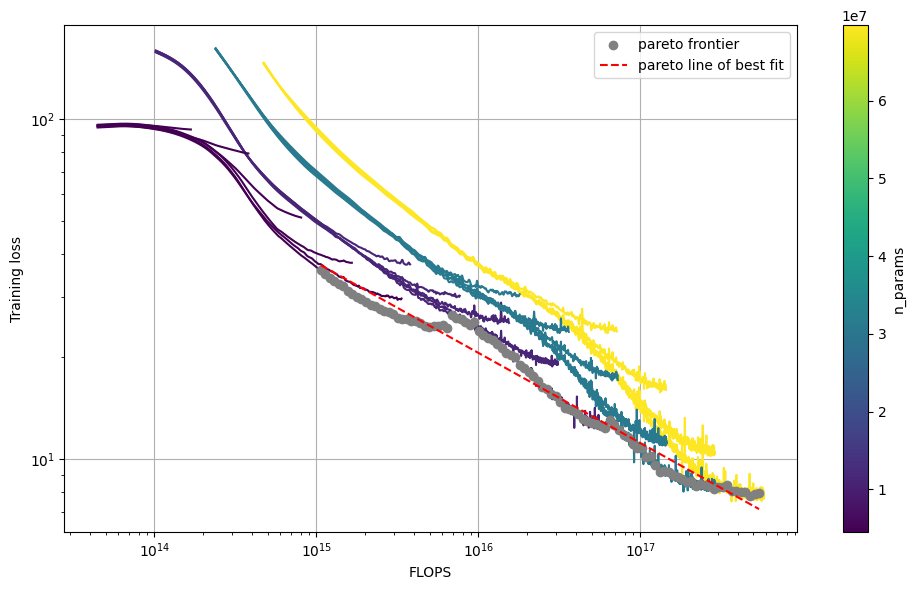

In [22]:
# create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# colourmap
cmap = plt.cm.viridis  # 'plasma', 'inferno', 'magma', 'jet'
norm = Normalize(vmin=min(flops_and_losses), vmax=max(flops_and_losses))

# plot training curves
for n_params in flops_and_losses:
    for flops, smooth_losses in flops_and_losses[n_params]:
        ax.plot(flops, smooth_losses, color=cmap(norm(n_params)), markersize=2)

# plot pareto frontier
ax.scatter(pareto.keys(), pareto.values(), color='gray', zorder=3, label='pareto frontier')
ax.plot(all_flops, pareto_lobf, ls='--', color='red', label='pareto line of best fit', zorder=4)
    
# colourbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('n_params')

# labels
ax.set_xlabel('FLOPS')
ax.set_ylabel('Training loss')
ax.grid(True)
ax.legend()

# log scale
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

### Extrapolate

In [64]:
def pareto_extrapolate(flops):
    slope = regress[0]
    intercept = regress[1]

    return 2 ** (slope * np.log2(flops) + intercept)

pareto_extrapolate(1e19)

np.float64(3.2982266031167917)